Step 1: Data Ingestion

In [2]:
import pandas as pd

df = pd.read_csv("zomato.csv", encoding='latin1')
print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

Step 2: Data Cleaning

In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df['Average Cost for two'] = df['Average Cost for two'].astype(int)
df['Aggregate rating'] = df['Aggregate rating'].astype(float)

In [6]:
df = df[df['Rating text'] != 'NEW']
df = df[df['Rating text'] != '-']

Step 3: Feature Engineering

In [9]:
df['Cost_per_person'] = df['Average Cost for two'] / 2

df['Online Delivery'] = df['Has Online delivery'].map({'Yes':1, 'No':0})
df['Table booking'] = df['Has Table booking'].map({'Yes':1, 'No':0})

Step 4: Store in SQL

In [10]:
import sqlite3

conn = sqlite3.connect("zomato.db")
df.to_sql("restaurants", conn, if_exists="replace", index=False)

9542

Step 5: Data Analysis (Business Insights)

In [12]:
df['City'].value_counts().head(10)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Ahmedabad,21
Lucknow,21
Guwahati,21


Best Restaurant

In [14]:
df.sort_values(by='Aggregate rating', ascending=False).head(10)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cost_per_person,Online Delivery,Table booking
9524,6004011,Gaga Manjero,208,Ankara,"Gazi Osman Paôa Mahallesi, Filistin Caddesi, ...",Gazi Osman Paôa,"Gazi Osman Paôa, Ankara",32.869800,39.898239,World Cuisine,...,No,No,3,4.9,Dark Green,Excellent,95,40.0,0,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,4,4.9,Dark Green,Excellent,365,750.0,0,0
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980090,14.552990,"European, Asian, Indian",...,No,No,4,4.9,Dark Green,Excellent,621,3000.0,0,1
637,3400346,Sheroes Hangout,1,Agra,"Opposite The Gateway Hotel, Fatehabad Road, Ta...",Tajganj,"Tajganj, Agra",78.040165,27.161850,"Cafe, North Indian, Chinese",...,No,No,1,4.9,Dark Green,Excellent,77,0.0,0,0
9514,5800176,Ministry of Crab,191,Colombo,"Old Colombo Dutch Hospital, Fort, Colombo 01","Old Dutch Hospital, Fort","Old Dutch Hospital, Fort, Colombo",79.844239,6.932814,Seafood,...,No,No,4,4.9,Dark Green,Excellent,203,2000.0,0,0
324,17500759,Ingleside Village Pizza,216,Macon,"2395 Ingleside Ave, Macon, GA 31204",Macon,"Macon, Macon",-83.657061,32.853896,"Pizza, Sandwich",...,No,No,1,4.9,Dark Green,Excellent,478,5.0,0,0
4298,18345728,Masala Library,1,New Delhi,"21 A, Janpath, New Delhi",Janpath,"Janpath, New Delhi",77.218645,28.618245,Modern Indian,...,No,No,4,4.9,Dark Green,Excellent,408,2500.0,0,0
304,17375072,Atlanta Highway Seafood Market,216,Gainesville,"227 Atlanta Highway Suite 900, Gainesville, GA...",Gainesville,"Gainesville, Gainesville",-83.838457,34.285102,"Sandwich, Seafood, Cajun",...,No,No,2,4.9,Dark Green,Excellent,681,12.5,0,0
50,7300515,Garota de Ipanema,30,Rio de Janeiro,"Rua Vinicius de Moraes, 49, Ipanema, Rio de Ja...",Ipanema,"Ipanema, Rio de Janeiro",-43.203000,-22.985333,"Brazilian, Bar Food",...,No,No,4,4.9,Dark Green,Excellent,49,60.0,0,0
580,5703500,Punjab Grill,214,Abu Dhabi,"Venetian Village, Ritz Carlton Abu Dhabi, Gran...","Venetian Village, Al Maqtaa","Venetian Village, Al Maqtaa, Abu Dhabi",54.487214,24.410615,"Indian, North Indian",...,No,No,4,4.9,Dark Green,Excellent,216,165.0,0,1


Cost vs Rating

In [16]:
df[['Cost_per_person', 'Aggregate rating']].corr()

,Cost_per_person,Aggregate rating
Cost_per_person,1.000000,0.051864
Aggregate rating,0.051864,1.000000


Step 6: Visualization

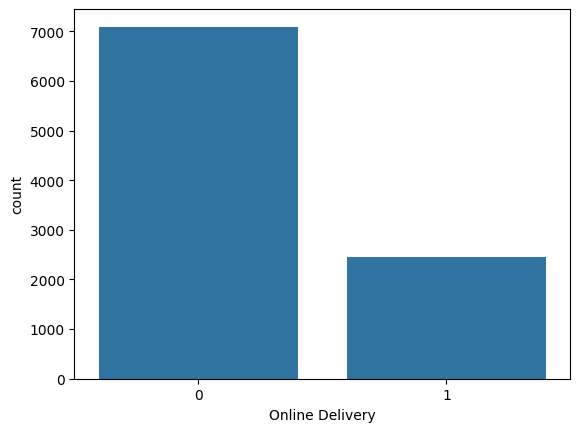

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Online Delivery', data=df)
plt.show()